In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lsind18/gemstones-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gemstones-images' dataset.
Path to dataset files: /kaggle/input/gemstones-images


In [ ]:
import tensorflow as tf

gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print("GPU is available:", gpu_available)
    print("TensorFlow will use GPU.")
else:
    print("No GPU available. TensorFlow will use CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow will use GPU.


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# The path variable from the previous cell should contain the dataset root
# We need to find the subdirectory containing the actual images
# Assuming the images are directly under 'path' or in a subdirectory like 'gemstones-images'

# Let's verify the structure. 'path' is /kaggle/input/gemstones-images
# We need to check what's inside this directory.
# Based on typical Kaggle datasets, images are often in subfolders for each class.

# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Use 20% of data for validation
)

# It's common for Kagglehub datasets to be extracted to a subfolder with the same name as the dataset slug
dataset_root = os.path.join(path, 'gemstones-images') # Adjust this if the structure is different

# Check if the assumed dataset_root exists and contains directories
if not os.path.exists(dataset_root):
    print(f"Dataset root not found at {dataset_root}. Listing contents of {path}...")
    for item in os.listdir(path):
        print(item)
    print("Please adjust 'dataset_root' if the images are in a different subdirectory.")
    # Fallback: if 'gemstones-images' is not directly under 'path', assume 'path' is the root
    dataset_root = path
    print(f"Proceeding with dataset_root = {dataset_root}")


train_generator = train_datagen.flow_from_directory(
    dataset_root,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_root,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Get number of classes
num_classes = train_generator.num_classes
print(f"Number of classes found: {num_classes}")

# Build the ResNet50 model for transfer learning
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze the base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
EPOCHS = 20 # You can increase this for better performance
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)


Dataset root not found at /kaggle/input/gemstones-images/gemstones-images. Listing contents of /kaggle/input/gemstones-images...
test
train
Please adjust 'dataset_root' if the images are in a different subdirectory.
Proceeding with dataset_root = /kaggle/input/gemstones-images
Found 2576 images belonging to 2 classes.
Found 643 images belonging to 2 classes.
Number of classes found: 2


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,687,938 (97.99 MB)

 Trainable params: 2,100,226 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 710ms/step - accuracy: 0.8793 - loss: 0.3748 - val_accuracy: 0.8880 - val_loss: 0.3621
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 553ms/step - accuracy: 0.8870 - loss: 0.3646 - val_accuracy: 0.8880 - val_loss: 0.3636
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 529ms/step - accuracy: 0.8870 - loss: 0.3584 - val_accuracy: 0.8880 - val_loss: 0.3507
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - accuracy: 0.8870 - loss: 0.3628 - val_accuracy: 0.8880 - val_loss: 0.3498
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 541ms/step - accuracy: 0.8870 - loss: 0.3581 - val_accuracy: 0.8880 - val_loss: 0.3522
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 81s 530ms/step - accuracy: 0.8870 - loss: 0.3581 - val_accuracy: 0.8880 - val_loss: 0.3492
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 535ms/step - accuracy: 0.8870 - loss: 0.3573 - val_accuracy: 0.8880 - val_loss: 0.3600
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 555ms/step - accuracy: 0.8870 - loss: 0.3533 - val_accu

In [ ]:
print("\n--- Training Summary ---")

# Get the final validation accuracy and loss
final_accuracy = history.history['val_accuracy'][-1]
final_loss = history.history['val_loss'][-1]

print(f"Final Validation Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Loss: {final_loss:.4f}")

print("Training complete! The model has been trained.")


--- Training Summary ---
Final Validation Accuracy: 0.8880
Final Validation Loss: 0.3495
Training complete! The model has been trained.


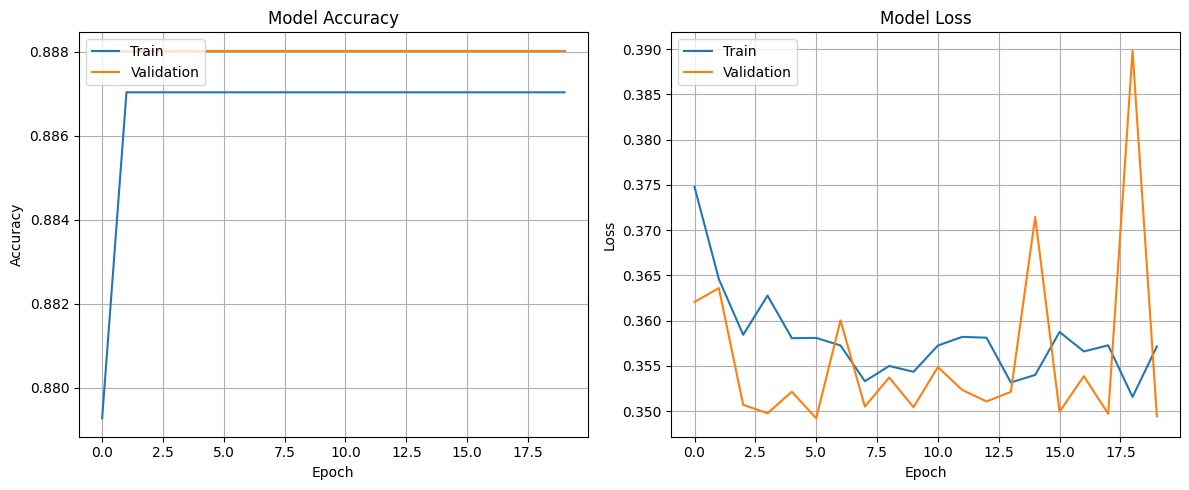

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()